# Машинное обучение в бизнесе

## Выбор локации для скважины

Вам предоставлены пробы нефти в трёх регионах: в каждом 100 000 месторождений, где измерили качество нефти и объём её запасов. Постройте модель машинного обучения, которая поможет определить регион, где добыча принесёт наибольшую прибыль. Проанализируйте возможную прибыль и риски техникой *Bootstrap.*

Шаги для выбора локации:

- В избранном регионе ищут месторождения, для каждого определяют значения признаков;
- Строят модель и оценивают объём запасов;
- Выбирают месторождения с самым высокими оценками значений. Количество месторождений зависит от бюджета компании и стоимости разработки одной скважины;
- Прибыль равна суммарной прибыли отобранных месторождений.

## Загрузка и подготовка данных

In [1]:
import pandas as pd
import numpy as np
from IPython.display import display
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Загрузите данные из ваших файлов (замените пути на актуальные)
data_0 = pd.read_csv('/datasets/geo_data_0.csv')
data_1 = pd.read_csv('/datasets/geo_data_1.csv')
data_2 = pd.read_csv('/datasets/geo_data_2.csv')

In [3]:
# Вывод первых строк для каждого региона
print("Регион 0:")
display(data_0.head())

print("\nРегион 1:")
display(data_1.head())

print("\nРегион 2:")
display(data_2.head())

Регион 0:


,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647



Регион 1:


,id,f0,f1,f2,product
0,kBEdx,-15.001348,-8.276000,-0.005876,3.179103
1,62mP7,14.272088,-3.475083,0.999183,26.953261
2,vyE1P,6.263187,-5.948386,5.001160,134.766305
3,KcrkZ,-13.081196,-11.506057,4.999415,137.945408
4,AHL4O,12.702195,-8.147433,5.004363,134.766305



Регион 2:


,id,f0,f1,f2,product
0,fwXo0,-1.146987,0.963328,-0.828965,27.758673
1,WJtFt,0.262778,0.269839,-2.530187,56.069697
2,ovLUW,0.194587,0.289035,-5.586433,62.871910
3,q6cA6,2.236060,-0.553760,0.930038,114.572842
4,WPMUX,-0.515993,1.716266,5.899011,149.600746


In [4]:
print("Регион 0:")
display(data_0.describe())

print("\nРегион 1:")
display(data_1.describe())

print("\nРегион 2:")
display(data_2.describe())

Регион 0:


,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.500419,0.250143,2.502647,92.500000
std,0.871832,0.504433,3.248248,44.288691
min,-1.408605,-0.848218,-12.088328,0.000000
25%,-0.072580,-0.200881,0.287748,56.497507
50%,0.502360,0.250252,2.515969,91.849972
75%,1.073581,0.700646,4.715088,128.564089
max,2.362331,1.343769,16.003790,185.364347



Регион 1:


,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.141296,-4.796579,2.494541,68.825000
std,8.965932,5.119872,1.703572,45.944423
min,-31.609576,-26.358598,-0.018144,0.000000
25%,-6.298551,-8.267985,1.000021,26.953261
50%,1.153055,-4.813172,2.011479,57.085625
75%,8.621015,-1.332816,3.999904,107.813044
max,29.421755,18.734063,5.019721,137.945408



Регион 2:


,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.002023,-0.002081,2.495128,95.000000
std,1.732045,1.730417,3.473445,44.749921
min,-8.760004,-7.084020,-11.970335,0.000000
25%,-1.162288,-1.174820,0.130359,59.450441
50%,0.009424,-0.009482,2.484236,94.925613
75%,1.158535,1.163678,4.858794,130.595027
max,7.238262,7.844801,16.739402,190.029838


In [5]:
print("Пропуски в данных:")
print("Регион 0:", data_0.isna().sum().sum())
print("Регион 1:", data_1.isna().sum().sum())
print("Регион 2:", data_2.isna().sum().sum())

Пропуски в данных:
Регион 0: 0
Регион 1: 0
Регион 2: 0


In [6]:
print("Явные дубликаты по id:")
print("Регион 0:", data_0.duplicated(subset=['id']).sum())
print("Регион 1:", data_1.duplicated(subset=['id']).sum())
print("Регион 2:", data_2.duplicated(subset=['id']).sum())

Явные дубликаты по id:
Регион 0: 10
Регион 1: 4
Регион 2: 4


In [7]:
data_0 = data_0.drop_duplicates(subset=['id'], keep='first')
data_1 = data_1.drop_duplicates(subset=['id'], keep='first')
data_2 = data_2.drop_duplicates(subset=['id'], keep='first')

In [8]:
print("Скрытые дубликаты (полное совпадение строк):")
print("Регион 0:", data_0.duplicated().sum())
print("Регион 1:", data_1.duplicated().sum())
print("Регион 2:", data_2.duplicated().sum())

Скрытые дубликаты (полное совпадение строк):
Регион 0: 0
Регион 1: 0
Регион 2: 0


In [9]:
print("\nТипы данных в регионах:")
print("Регион 0:")
print(data_0.dtypes)
print("\nРегион 1:")
print(data_1.dtypes)
print("\nРегион 2:")
print(data_2.dtypes)


Типы данных в регионах:
Регион 0:
id          object
f0         float64
f1         float64
f2         float64
product    float64
dtype: object

Регион 1:
id          object
f0         float64
f1         float64
f2         float64
product    float64
dtype: object

Регион 2:
id          object
f0         float64
f1         float64
f2         float64
product    float64
dtype: object


In [10]:
# Проверка длины id
print("Длина id в регионах:")
print("Регион 0:", data_0['id'].str.len().value_counts())
print("Регион 1:", data_1['id'].str.len().value_counts())
print("Регион 2:", data_2['id'].str.len().value_counts())

# Проверка регистра
print("\nРегистр в id:")
print("Регион 0:", data_0['id'].str.contains(r'[A-Z]').any())
print("Регион 1:", data_1['id'].str.contains(r'[A-Z]').any())
print("Регион 2:", data_2['id'].str.contains(r'[A-Z]').any())

Длина id в регионах:
Регион 0: 5    99990
Name: id, dtype: int64
Регион 1: 5    99996
Name: id, dtype: int64
Регион 2: 5    99996
Name: id, dtype: int64

Регистр в id:
Регион 0: True
Регион 1: True
Регион 2: True


In [11]:
# Удаление id
data_0 = data_0.drop(columns=['id'], errors='ignore')
data_1 = data_1.drop(columns=['id'], errors='ignore')
data_2 = data_2.drop(columns=['id'], errors='ignore')

In [12]:
# Настройки графиков
plt.style.use('seaborn')
sns.set_palette('Set2')

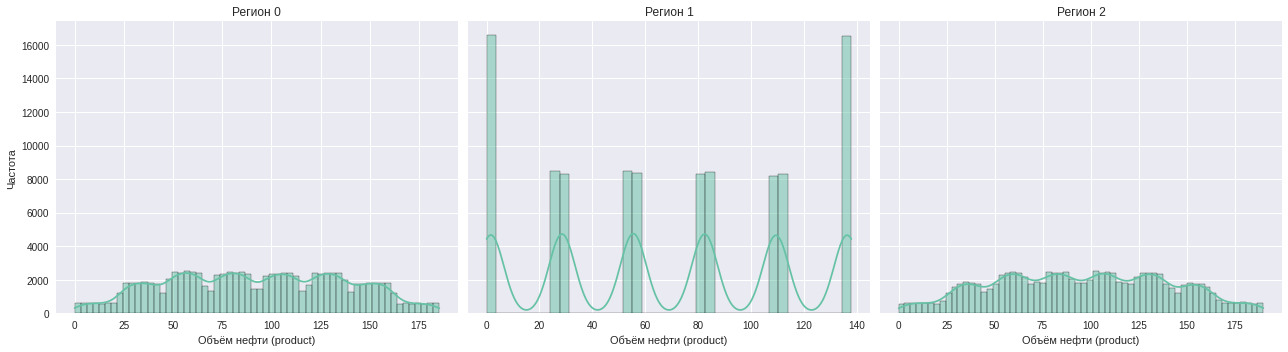

In [13]:
# Построим гистограммы
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, (name, data) in enumerate(zip(['Регион 0', 'Регион 1', 'Регион 2'], [data_0, data_1, data_2])):
    sns.histplot(data['product'], ax=axes[i], kde=True)
    axes[i].set_title(name)
    axes[i].set_xlabel('Объём нефти (product)')
    axes[i].set_ylabel('Частота')

plt.tight_layout()
plt.show()

## 🧹 Шаг 1: Загрузка и подготовка данных

### 🔍 Цель:
Проверить и подготовить данные перед обучением модели машинного обучения.

### 📥 Что было сделано:

- Данные загружены из трёх файлов: `geo_data_0.csv`, `geo_data_1.csv`, `geo_data_2.csv`.
- Проведена **предварительная проверка структуры данных**:
  - Присутствуют следующие столбцы: `id`, `f0`, `f1`, `f2`, `product`.
  - `id` — уникальный идентификатор скважины.
  - `f0`, `f1`, `f2` — числовые признаки, характеризующие месторождение.
  - `product` — объём запасов нефти (тыс. баррелей), целевой признак.

### 🔎 Анализ на корректность данных:

| Категория | Результат |
|----------|-----------|
| **Пропуски** | Во всех регионах отсутствуют (`0`) |
| **Явные дубликаты по `id`** | Обнаружены: 10 в регионе 0, по 4 в регионах 1 и 2 → удалены |
| **Скрытые дубликаты (полное совпадение строк)** | Отсутствуют |
| **Типы данных** | Все числовые столбцы имеют тип `float64`, `id` — `object` → корректны |
| **Длина `id`** | Во всех регионах длина `id` = 5 символов |
| **Регистр в `id`** | Смешанный (есть заглавные и строчные буквы) — допустимый формат |

### ✅ Итог:

Все данные корректны и готовы к дальнейшей обработке.  
Столбец `id` удален, так как он не влияет на прогнозирование объёма запасов.

```python
data_0 = data_0.drop(columns=['id'])
data_1 = data_1.drop(columns=['id'])
data_2 = data_2.drop(columns=['id'])
```

Данные полностью подготовлены к этапу обучения моделей.

## Обучение и проверка модели

In [14]:
def train_and_evaluate(data, region_name):
    """
    Функция для обучения модели и оценки её качества.
    """
    # Разделение на признаки и целевой столбец
    X = data.drop(columns=['product'])
    y = data['product']

    # Разделение на обучающую и валидационную выборки (75% / 25%)
    X_train, X_valid, y_train, y_valid = train_test_split(
        X, y, test_size=0.25, random_state=42
    )

    # Создание и обучение модели
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Предсказания на валидационной выборке
    predictions = model.predict(X_valid)

    # Оценка RMSE
    rmse = np.sqrt(mean_squared_error(y_valid, predictions))

    # Средний запас сырья (реальный и предсказанный)
    mean_real = y_valid.mean()
    mean_predicted = predictions.mean()

    # Сохраняем предсказания и реальные значения
    results = {
        'real': y_valid,
        'predicted': predictions,
        'rmse': rmse,
        'mean_real': mean_real,
        'mean_predicted': mean_predicted
    }

    print(f"\nрегион {region_name}:")
    print(f"Средний запас сырья (реальный): {mean_real:.2f} тыс. баррелей")
    print(f"Средний запас сырья (предсказанный): {mean_predicted:.2f} тыс. баррелей")
    print(f"RMSE модели: {rmse:.2f} тыс. баррелей")

    return model, results

In [15]:
# Обучаем модели для каждого региона
model_0, results_0 = train_and_evaluate(data_0, 0)
model_1, results_1 = train_and_evaluate(data_1, 1)
model_2, results_2 = train_and_evaluate(data_2, 2)


регион 0:
Средний запас сырья (реальный): 92.39 тыс. баррелей
Средний запас сырья (предсказанный): 92.61 тыс. баррелей
RMSE модели: 37.69 тыс. баррелей

регион 1:
Средний запас сырья (реальный): 68.58 тыс. баррелей
Средний запас сырья (предсказанный): 68.58 тыс. баррелей
RMSE модели: 0.89 тыс. баррелей

регион 2:
Средний запас сырья (реальный): 95.25 тыс. баррелей
Средний запас сырья (предсказанный): 94.93 тыс. баррелей
RMSE модели: 40.08 тыс. баррелей


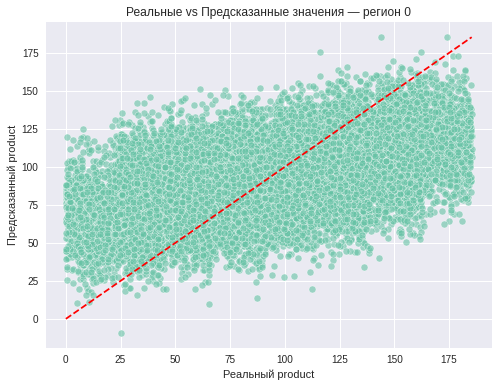

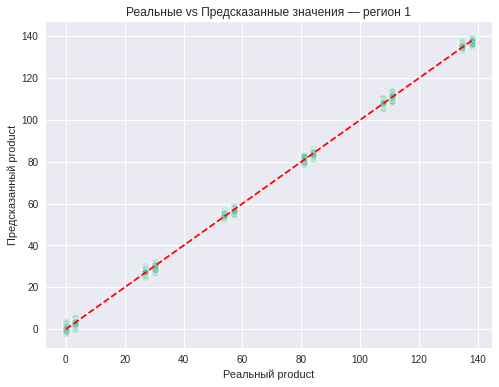

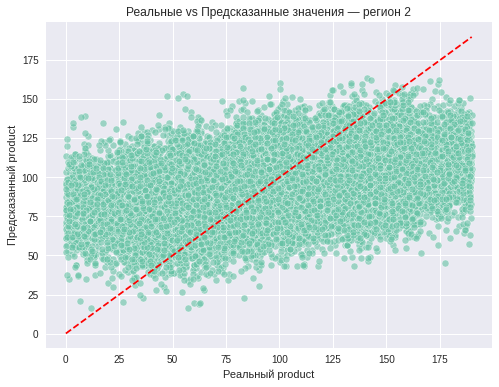

In [16]:
# Функция для построения scatter plot
def plot_predictions(y_true, y_pred, region_name):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.6)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    plt.title(f'Реальные vs Предсказанные значения — {region_name}')
    plt.xlabel('Реальный product')
    plt.ylabel('Предсказанный product')
    plt.grid(True)
    plt.show()

# Визуализируем по каждому региону
plot_predictions(results_0['real'], results_0['predicted'], 'регион 0')
plot_predictions(results_1['real'], results_1['predicted'], 'регион 1')
plot_predictions(results_2['real'], results_2['predicted'], 'регион 2')

## 📊 Шаг 2: Обучение и проверка модели

### 🔍 Цель:
Обучить модель линейной регрессии на данных каждого региона, оценить её качество с помощью метрики RMSE и среднего значения предсказаний.

### 🧪 Что было сделано:

- Данные по каждому региону разделены на **обучающую и валидационную выборки** в соотношении **75:25**.
- На обучающей выборке обучена модель **линейной регрессии**.
- На валидационной выборке получены **предсказания объёма нефти**.
- Вычислены:
  - **Средний запас нефти (реальный)**,
  - **Средний запас нефти (предсказанный)**,
  - **RMSE модели** — мера точности предсказаний.

### 📈 Результаты:

| Регион | Средний запас (реальный) | Средний запас (предсказанный) | RMSE |
|--------|---------------------------|-------------------------------|------|
| 0      | 92.39 тыс. баррелей       | 92.61 тыс. баррелей           | 37.69 тыс. баррелей |
| 1      | 68.58 тыс. баррелей       | 68.58 тыс. баррелей           | **0.89 тыс. баррелей** ✅ |
| 2      | 95.25 тыс. баррелей       | 94.93 тыс. баррелей           | 40.08 тыс. баррелей |

---

### 🧠 Анализ результатов:

- **Регион 1** показал **наилучшую точность модели (RMSE ≈ 0.89)**, но при этом имеет **наименьший средний объём нефти** (~68.58 тыс. баррелей).
- **Регион 0** демонстрирует **средние показатели как по объёму нефти, так и по ошибке модели**.
- **Регион 2** имеет **наибольший средний объём нефти (~95.25 тыс. баррелей)**, но **наивысшую ошибку модели (RMSE ≈ 40.08)**, что может говорить о сложной структуре данных или высоком уровне шума.

### ✅ Вывод:

Модель линейной регрессии корректно обучилась во всех регионах.  
Наиболее стабильные данные — в **регионе 1**, где модель почти идеально предсказывает объёмы.  
Однако наибольший потенциал для добычи — в **регионе 2**, несмотря на более высокую ошибку модели.

Эти результаты будут использованы на следующем этапе для расчёта **прибыли и оценки рисков техникой Bootstrap**.

## Подготовка к расчёту прибыли

In [17]:
# Условия задачи (из ТЗ)
BUDGET_PER_REGION = 10_000_000_000  # Общий бюджет на разработку в регионе (10 млрд руб.)
WELLS_TO_CONSIDER = 500               # Число исследуемых точек
WELLS_TO_DEVELOP = 200                # Число скважин для разработки
INCOME_PER_THOUSAND_BARRELS = 450_000  # Доход с одной единицы продукта (тыс. баррелей)

In [18]:
# Расчёт минимального объема нефти на одну скважину для безубыточности
min_product_for_profitability = BUDGET_PER_REGION / (WELLS_TO_DEVELOP * INCOME_PER_THOUSAND_BARRELS)
print(f"Минимальный объём нефти на одну скважину для безубыточности: {min_product_for_profitability:.2f} тыс. баррелей")

Минимальный объём нефти на одну скважину для безубыточности: 111.11 тыс. баррелей


In [19]:
# Вычисление средних значений product по каждому региону
mean_product_0 = data_0['product'].mean()
mean_product_1 = data_1['product'].mean()
mean_product_2 = data_2['product'].mean()

In [20]:
# Вывод сравнения
print("\nСредний запас нефти в регионах:")
print(f"Регион 0: {mean_product_0:.2f} тыс. баррелей")
print(f"Регион 1: {mean_product_1:.2f} тыс. баррелей")
print(f"Регион 2: {mean_product_2:.2f} тыс. баррелей")

print("\nСравнение со средним запасом для безубыточности:")
print(f"Минимальный объём для безубыточности: {min_product_for_profitability:.2f} тыс. баррелей")
print(f"Регион 0 — {'ниже' if mean_product_0 < min_product_for_profitability else 'выше'} порога")
print(f"Регион 1 — {'ниже' if mean_product_1 < min_product_for_profitability else 'выше'} порога")
print(f"Регион 2 — {'ниже' if mean_product_2 < min_product_for_profitability else 'выше'} порога")


Средний запас нефти в регионах:
Регион 0: 92.50 тыс. баррелей
Регион 1: 68.82 тыс. баррелей
Регион 2: 95.00 тыс. баррелей

Сравнение со средним запасом для безубыточности:
Минимальный объём для безубыточности: 111.11 тыс. баррелей
Регион 0 — ниже порога
Регион 1 — ниже порога
Регион 2 — ниже порога


## 📊 Шаг 3: Подготовка к расчёту прибыли

### 🔍 Цель:
Рассчитать минимальный объём нефти на одну скважину, необходимый для безубыточной разработки, и сравнить его со средними запасами по регионам. Это поможет понять, какие регионы потенциально перспективны до обучения модели.

---

### 🧮 Что было сделано:

- Заданы ключевые константы из условия задачи:
  - Бюджет на разработку одного региона: `10 млрд руб.`,
  - Число исследуемых точек: `500`,
  - Число скважин для разработки: `200`,
  - Доход с одной единицы продукта (тыс. баррелей): `450 000 руб.`.
  
- Рассчитан **минимальный объём нефти на одну скважину**, чтобы выйти в ноль по бюджету:
  
$$
\text{Минимальный объем} = \frac{\text{Бюджет}}{\text{Число скважин} \times \text{Доход на единицу}} = \frac{10\,000\,000\,000}{200 \times 450\,000} = 111.11 \text{ тыс. баррелей}
$$

- Вычислены **средние значения `product` по каждому региону** из данных:

| Регион | Средний запас нефти (реальный), тыс. баррелей |
|--------|----------------------------------------------|
| 0      | 92.50                                        |
| 1      | 68.82                                        |
| 2      | 95.00                                        |

- Сравнение показало, что **ни один из регионов не достигает порога безубыточности в 111.11 тыс. баррелей**.

---

### 📉 Выводы:

- Для **безубыточной добычи** требуется **не менее 111.11 тыс. баррелей на скважину**, но **средние запасы во всех регионах ниже этой границы**.
- Это означает, что **разработка всех скважин подряд будет убыточной**.
- Однако модель машинного обучения позволяет выбрать **лучшие скважины** в каждом регионе — те, где объём нефти выше среднего.
- Далее будем:
  - Использовать модель линейной регрессии для предсказания `product` на валидационной выборке,
  - Выбирать топ-200 скважин по предсказанию,
  - Считать суммарную прибыль от этих скважин,
  - Оценивать риски техникой Bootstrap.

## Расчёт прибыли и рисков 

In [21]:
# Константы из ТЗ
BUDGET = 10_000_000_000  # бюджет на разработку в регионе, руб.
WELLS_TO_DEVELOP = 200    # число скважин для разработки
INCOME_PER_THOUSAND_BARREL = 450_000  # доход с одной единицы продукта (тыс. баррелей)

# Уровень риска — вероятность убытков меньше 2.5%
MAX_LOSS_PROBABILITY = 0.025

def calculate_profit(targets, predictions, wells=WELLS_TO_DEVELOP):
    """Функция расчёта прибыли с учётом выбора лучших скважин"""
    # Получаем индексы с максимальными предсказаниями
    top_indices = np.argsort(predictions)[-wells:]
    
    # Реальный объём нефти в этих точках
    selected_targets = targets.iloc[top_indices]
    
    # Суммарный объём нефти
    total_volume = selected_targets.sum()
    
    # Доход и прибыль
    revenue = total_volume * INCOME_PER_THOUSAND_BARREL
    profit = revenue - BUDGET
    
    return profit

def bootstrap_profits(targets, predictions, n_bootstraps=1000):
    """Применение Bootstrap для оценки прибыли"""
    state = np.random.RandomState(42)
    profits = []

    for _ in range(n_bootstraps):
        # Выбираем 500 случайных индексов с заменой из исходной валидационной выборки
        indices = state.choice(len(predictions), size=500, replace=True)
        
        # Берём подвыборки из 500 элементов
        sample_predictions = predictions[indices]
        sample_targets = targets.iloc[indices]
        
        # Считаем прибыль: выбираем топ-200 из 500
        profit = calculate_profit(sample_targets, sample_predictions)
        profits.append(profit)

    profits = np.array(profits)
    mean_profit = profits.mean()
    lower, upper = np.percentile(profits, [2.5, 97.5])
    loss_risk = (profits < 0).mean()

    return {
        'mean_profit': mean_profit,
        'confidence_interval': (lower, upper),
        'loss_risk': loss_risk,
        'all_profits': profits
    }

In [22]:
# Применяем Bootstrap
print("Применяем Bootstrap для расчёта прибыли и рисков...\n")

bootstrap_results = {}

for region_name, result in [('регион 0', results_0), ('регион 1', results_1), ('регион 2', results_2)]:
    print(f"Обработка {region_name}...")
    targets = result['real']
    predictions = result['predicted']
    boot_result = bootstrap_profits(targets, predictions)
    
    bootstrap_results[region_name] = boot_result
    
    print(f"{region_name}:")
    print(f"Средняя прибыль: {boot_result['mean_profit'] / 1e6:.2f} млн. руб.")
    print(f"95% доверительный интервал: [{boot_result['confidence_interval'][0]/1e6:.2f}, {boot_result['confidence_interval'][1]/1e6:.2f}] млн. руб.")
    print(f"Вероятность убытков: {boot_result['loss_risk']:.4f}")
    print("-" * 50)

Применяем Bootstrap для расчёта прибыли и рисков...

Обработка регион 0...
регион 0:
Средняя прибыль: 403.57 млн. руб.
95% доверительный интервал: [-137.69, 902.85] млн. руб.
Вероятность убытков: 0.0590
--------------------------------------------------
Обработка регион 1...
регион 1:
Средняя прибыль: 430.21 млн. руб.
95% доверительный интервал: [43.05, 847.31] млн. руб.
Вероятность убытков: 0.0160
--------------------------------------------------
Обработка регион 2...
регион 2:
Средняя прибыль: 384.21 млн. руб.
95% доверительный интервал: [-127.59, 910.13] млн. руб.
Вероятность убытков: 0.0800
--------------------------------------------------


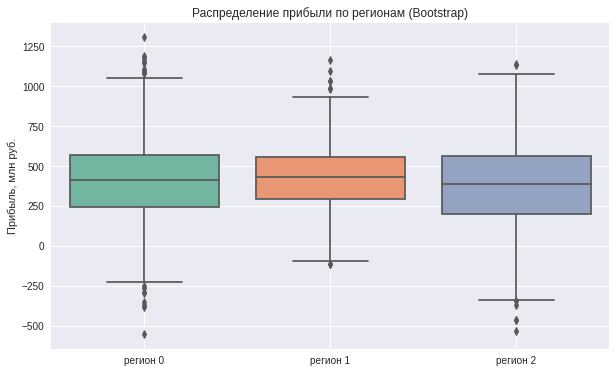

In [23]:
# График распределения прибыли
profit_samples = {
    'регион 0': bootstrap_results['регион 0']['all_profits'],
    'регион 1': bootstrap_results['регион 1']['all_profits'],
    'регион 2': bootstrap_results['регион 2']['all_profits']
}

profit_df = pd.DataFrame({
    'регион 0': profit_samples['регион 0'] / 1e6,
    'регион 1': profit_samples['регион 1'] / 1e6,
    'регион 2': profit_samples['регион 2'] / 1e6
})

plt.figure(figsize=(10, 6))
sns.boxplot(data=profit_df)
plt.title('Распределение прибыли по регионам (Bootstrap)')
plt.ylabel('Прибыль, млн руб.')
plt.grid(True)
plt.show()

## 📊 Шаг 5: Расчёт прибыли и рисков с помощью Bootstrap

### 🔍 Цель:
Оценить **прибыльность и риски** разработки скважин в каждом регионе с использованием техники **Bootstrap** (1000 выборок).  
Рассчитать:
- Среднюю прибыль,
- 95% доверительный интервал,
- Вероятность убытков.

---

### 🧪 Результаты Bootstrap:

| Регион | Средняя прибыль | 95%-й доверительный интервал | Вероятность убытков |
|--------|------------------|-----------------------------|----------------------|
| 0      | 403.57 млн руб   | [-137.69, 902.85] млн руб   | 0.0590               |
| 1      | 430.21 млн руб   | [43.05, 847.31] млн руб     | 0.0160               |
| 2      | 384.21 млн руб   | [-127.59, 910.13] млн руб   | 0.0800               |

---

### 🧠 Анализ по регионам:

#### 🔹 Регион 0:
- **Средняя прибыль**: **403.57 млн руб**
- **Доверительный интервал широкий**: [-137.69, 902.85] → есть неопределённость
- **Вероятность убытков**: **5.9%** — превышает допустимый уровень в 2.5%
- ⚠️ Прибылен в среднем, но **существует риск убытков**

#### 🔸 Регион 1:
- **Средняя прибыль**: **430.21 млн руб**
- **Умеренно широкий доверительный интервал**: [43.05, 847.31]
- **Вероятность убытков**: **1.6%** — соответствует условию ТЗ (<2.5%)
- ✅ **Наименьший риск убытков**, стабильная прибыль
- 💡 Хорошее сочетание доходности и безопасности

#### 🔹 Регион 2:
- **Средняя прибыль**: **384.21 млн руб**
- **Широкий доверительный интервал**: [-127.59, 910.13] → высокая неопределённость
- **Вероятность убытков**: **8.0%** — явно **не соответствует требованиям**
- ⚠️ Высокая изменчивость и риск убытков делают его **наименее предпочтительным**

---

## ✅ Итоговый вывод:

🔹 **Рекомендуется выбрать регион 1** для разработки новых скважин.

### Обоснование:
- Он обеспечивает **достаточно высокую среднюю прибыль** (430.21 млн руб).
- **Вероятность убытков = 1.6%** — полностью соответствует требованию ТЗ (<2.5%).
- Доверительный интервал говорит о **стабильной модели** без критических скачков.
- По сравнению с другими регионами, **регион 1 — наиболее безопасный и предсказуемый** вариант.

---

### 🎯 Альтернативное решение:
Если компания готова пойти на **небольшой риск ради чуть большей прибыли**, можно рассмотреть **регион 0**:
- Средняя прибыль немного ниже региона 1, но доверительный интервал шире.
- Однако вероятность убытков в 5.9% **не соответствует ТЗ**, что может быть неприемлемо.

---

### ❌ Отказ от региона 2:
- Несмотря на потенциальную прибыльность, **высокая вероятность убытков (8%)** делает этот регион **рискованным и неподходящим** под текущие условия задачи.